In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import stppsf
import stppsf.utils as utils
from stppsf.math_module import xp, _scipy, ensure_np_array
from stppsf.imshows import imshow1, imshow2, imshow3
import stppsf.esc_fresnel as esc
import stppsf.esc_optics as optics



In [3]:
reload(optics)

print(optics.apparent_fls_theo['m1'], optics.apparent_fls['m1'])
print(optics.apparent_fls_theo['m2'], optics.apparent_fls['m2'])
print(optics.apparent_fls_theo['m3'], optics.apparent_fls['m3'])
print()

reload(optics)

print('OAP1 Focal Length', optics.apparent_fls_theo['oap1'])
print('Distance from WCC_FP to OAP1: ', optics.distances['wcc_fp-oap1'])
print('Diff = ', optics.apparent_fls_theo['oap1'] - optics.distances['wcc_fp-oap1'])
print()
print('OAP2 Focal Length', optics.apparent_fls_theo['oap2'])
print('Distance from OAP2 to IFP1: ', optics.distances['oap2-ifp1'])
print('Diff = ', optics.apparent_fls_theo['oap2'] - optics.distances['oap2-ifp1'])
print()
print('OAP3 Focal Length', optics.apparent_fls_theo['oap3'])
print('Distance from IFP1 to OAP3: ', optics.distances['ifp1-oap3'])
print('Diff = ', optics.apparent_fls_theo['oap3'] - optics.distances['ifp1-oap3'])
print()
print('OAP4 Focal Length', optics.apparent_fls_theo['oap4'])
print('Distance from OAP4 to IFP2: ', optics.distances['oap4-ifp2'])
print('Diff = ', optics.apparent_fls_theo['oap4'] - optics.distances['oap4-ifp2'])
print()
print('OAP5 Focal Length', optics.apparent_fls_theo['oap5'])
print('Distance from IFP2 to OAP5: ', optics.distances['ifp2-oap5'])
print('Diff = ', optics.apparent_fls_theo['oap5'] - optics.distances['ifp2-oap5'])
print()
print('OAP6 Focal Length', optics.apparent_fls_theo['oap6'])
print('Distance from OAP6 to FPM: ', optics.distances['oap6-fpm'])
print('Diff = ', optics.apparent_fls_theo['oap6'] - optics.distances['oap6-fpm'])
print()
print('OAP7 Focal Length', optics.apparent_fls_theo['oap7'])
print('Distance from FPM to OAP7: ', optics.distances['fpm-oap7'])
print('Diff = ', optics.apparent_fls_theo['oap7'] - optics.distances['fpm-oap7'])
print()
print('OAP9 Focal Length', optics.apparent_fls_theo['oap9'])
print('Distance from OAP9 to fieldstop: ', optics.distances['oap9-fieldstop'])
print('Diff = ', optics.apparent_fls_theo['oap9'] - optics.distances['oap9-fieldstop'])
print()
print('Collimator Focal Length', optics.apparent_fls_theo['collimator'])
print('Distance from fieldstop to collimator: ', optics.distances['fieldstop-collimator'])
print('Diff = ', optics.apparent_fls_theo['collimator'] - optics.distances['fieldstop-collimator'])
print()
print('OAP10 Focal Length', optics.apparent_fls_theo['oap10'])
print('Distance from OAP10 to scicam: ', optics.distances['oap10-scicam'])
print('Diff = ', optics.apparent_fls_theo['oap10'] - optics.distances['oap10-scicam'])


8242.628147365896 mm 8242.74912529156 mm
-838.3055603795722 mm -843.722821101182 mm
941.4093047946056 mm 935.143362119169 mm

OAP1 Focal Length 510.55945420481845 mm
Distance from WCC_FP to OAP1:  510.5869985134304 mm
Diff =  -0.027544308611936685 mm

OAP2 Focal Length 102.25 mm
Distance from OAP2 to IFP1:  102.2237526492536 mm
Diff =  0.026247350746402276 mm

OAP3 Focal Length 75.11845070422535 mm
Distance from IFP1 to OAP3:  75.11509008726716 mm
Diff =  0.0033606169581901213 mm

OAP4 Focal Length 112.96 mm
Distance from OAP4 to IFP2:  112.9076777227092 mm
Diff =  0.052322277290798525 mm

OAP5 Focal Length 112.96 mm
Distance from IFP2 to OAP5:  112.907678555941 mm
Diff =  0.05232144405898964 mm

OAP6 Focal Length 462.6672222222222 mm
Distance from OAP6 to FPM:  464.3321137882849 mm
Diff =  -1.6648915660626926 mm

OAP7 Focal Length 206.21281249999998 mm
Distance from FPM to OAP7:  206.2190530703447 mm
Diff =  -0.006240570344715479 mm

OAP9 Focal Length 146.42857142857144 mm
Distance fr

In [2]:
m2_footprint = 2.113241E+02 - -7.265060E+00
# m2_footprint = -1.824447E+01 - -2.361855E+02
print(m2_footprint)

m3_footprint = 1.612959E+02 - 1.038096E+02
# m3_footprint = 6.869926E+01 -  1.112626E+01
print(m3_footprint)

m4_footprint = 3.386125E+00 - -2.845730E+01
# m4_footprint = 3.817123E+01 - 5.371454E+00
print(m4_footprint)

218.58916
57.486299999999986
31.843425


In [5]:
reload(optics)
print(optics.apparent_fls_theo['oap6'], optics.distances['oap6-fpm'], optics.apparent_fls['oap6'])
print(optics.apparent_fls_theo['oap7'], optics.distances['fpm-oap7'], optics.apparent_fls['oap7'])



462.6672222222222 mm 464.3321137882849 mm 464.3321137882849 mm
206.21281249999998 mm 206.2190530703447 mm 206.2190530703447 mm
206.21281249999998 mm 206.2190530703447 mm 253.8047651128181 mm


Propagating wavelength 650.000 nm.
PSF calculated in 0.337s


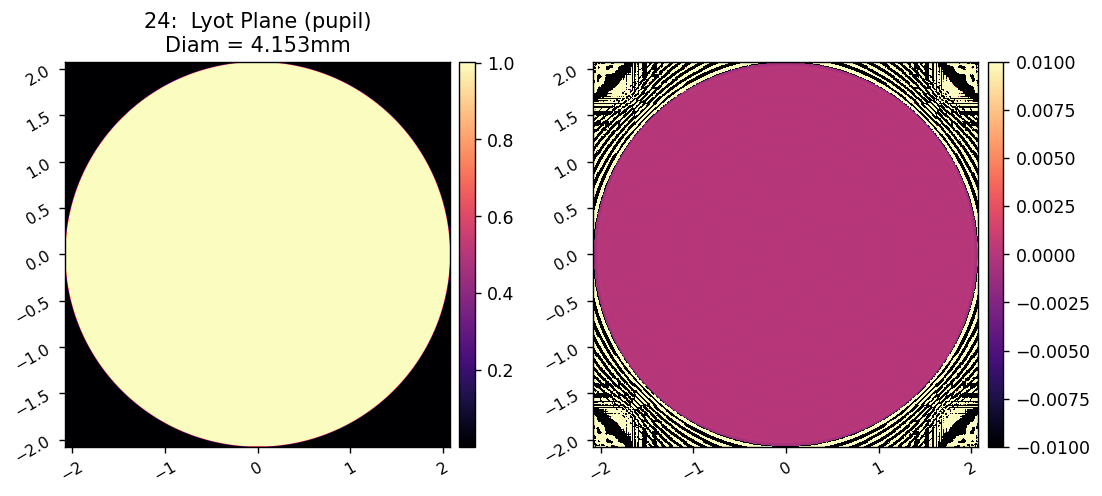

0: Entrance Pupil (subaperture) WF diam = 2430.000mm
1: m1 WF diam = 2430.000mm
2: m2 WF diam = 217.512mm
3: m3 WF diam = 57.912mm
4: m4 (pupil) WF diam = 31.623mm
5: WCC FP Focal Plane Correction:  0.0 mm
	Total focal length at focal plane = -97495.90
6: oap1 WF diam = 12.726mm
7: fm1 WF diam = 12.726mm
8: Pupil Mask WF diam = 12.726mm
9: oap2 WF diam = 12.726mm
10: ifp1 Focal Plane Correction:  0.0 mm
	Total focal length at focal plane = -0.00
11: oap3 WF diam = 9.351mm
12: FSM (pupil/sort of) WF diam = 9.351mm
13: fm2 WF diam = 9.351mm
14: oap4 WF diam = 9.351mm
15: ifp2 Focal Plane Correction:  0.0 mm
	Total focal length at focal plane = -0.00
16: oap5 WF diam = 9.351mm
17: DM (pupil) WF diam = 9.351mm
18: Input LP WF diam = 9.351mm
19: Input QWP WF diam = 9.351mm
20: oap6 WF diam = 9.351mm
21: FPM Focal Plane Correction:  -1541.0562467009754 mm
	Total focal length at focal plane = -0.00
22: Post FPM WF Focal Plane Correction:  0.0 mm
	Total focal length at focal plane = -0.00
23: 

In [10]:
reload(esc)
reload(optics)

M = esc.single(use_corrections=False)

M.wcc_corr = -0.0013996804923976924 *u.mm
M.ifp1_corr = -2.7895964649360394e-05 *u.mm
M.ifp2_corr = -0.00012892930811858605 *u.mm
M.fpm_corr = -0.00896733376620773 *u.mm
M.fieldstop_corr = -0.0072283463943279*u.mm
M.scicam_corr = -0.008480730812721049*u.mm

M.m4_corr = 4.75*u.mm
M.pupil_mask_corr = 8.25*u.mm
M.fsm_corr = -29.4*u.mm
M.dm_corr = -6.*u.mm

M.lyot_corr = -0.45*u.mm

wfs = M.calc_wfs()

i = 4 # M4
# i = 8 # Pupil mask
# i = 12 # FSM
i = 17 # DM
i = 24 # Lyot
wf = wfs[i]
imshow2(wf.amplitude, wf.phase, f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm', 
        pxscl=wf.pixelscale.to(u.mm/u.pix), npix=M.npix, 
        vmin2=-0.01, vmax2=0.01,
        )

for i,wf in enumerate(wfs):
        if 'fp' in wf.location.lower():
                f_corr = wf.z_w0 - wf.z
                print(f'{i:d}:'+wf.location[5:] + ' Focal Plane Correction: ', f_corr.to(u.mm))
                print(f'\tTotal focal length at focal plane = {wf.focal_length.to_value(u.mm):.2f}')
        else:
                print(f'{i:d}:'+wf.location[5:] + f' WF diam = {2*wf.spot_radius().to_value(u.mm):.3f}mm')

In [130]:
4.039635115946442E+001 * 2430, 4.007052360903806E+001 * 2430
(4.039635115946442E+001 * 2430 + 4.007052360903806E+001 * 2430)/2

97767.25284373053

https://arizona.app.box.com/folder/245321428353

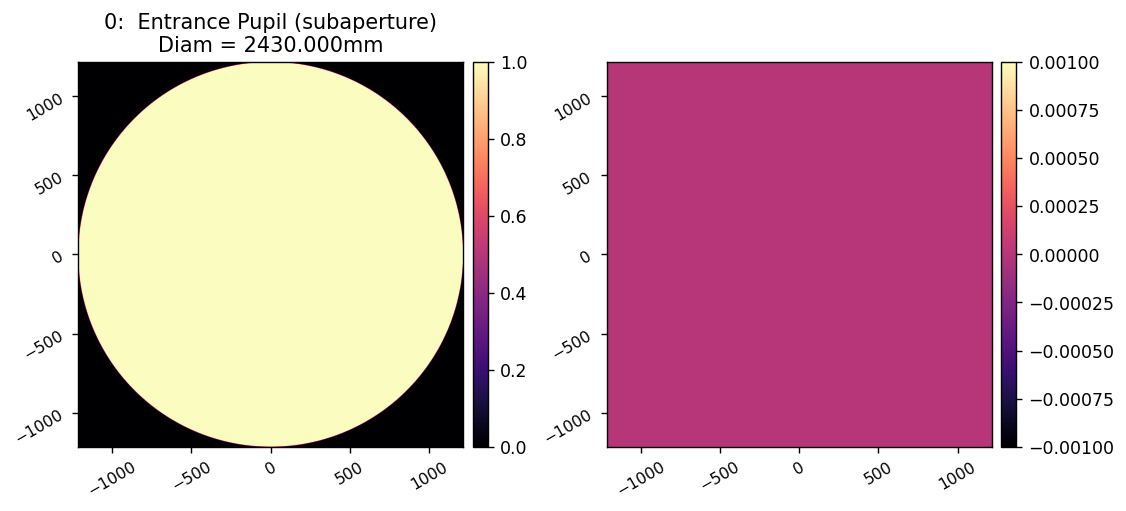

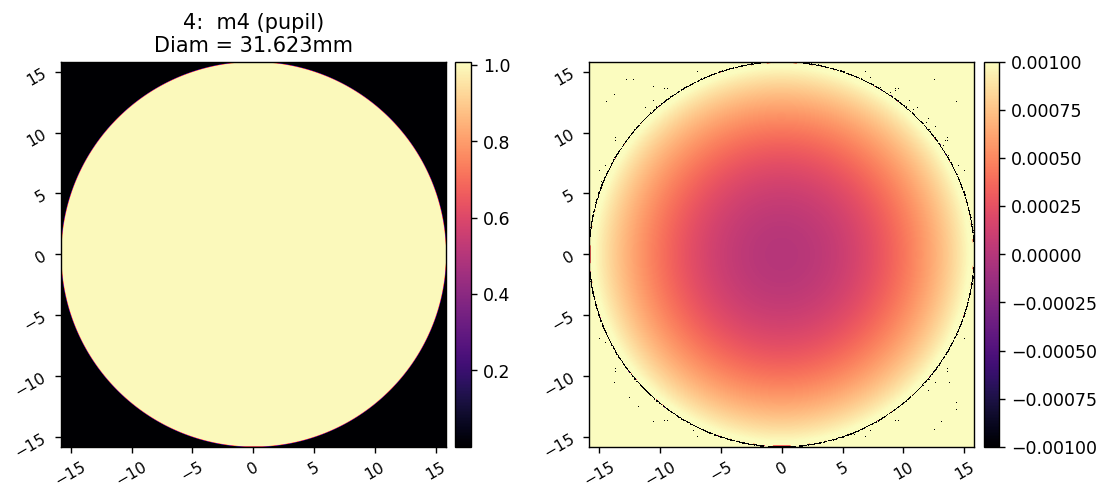

Focal Plane Correction:  0.0 mm


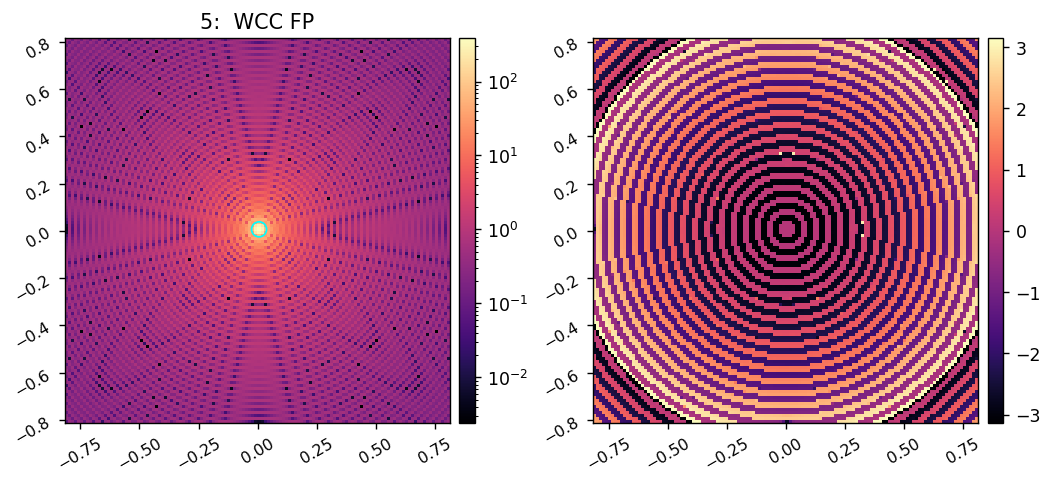

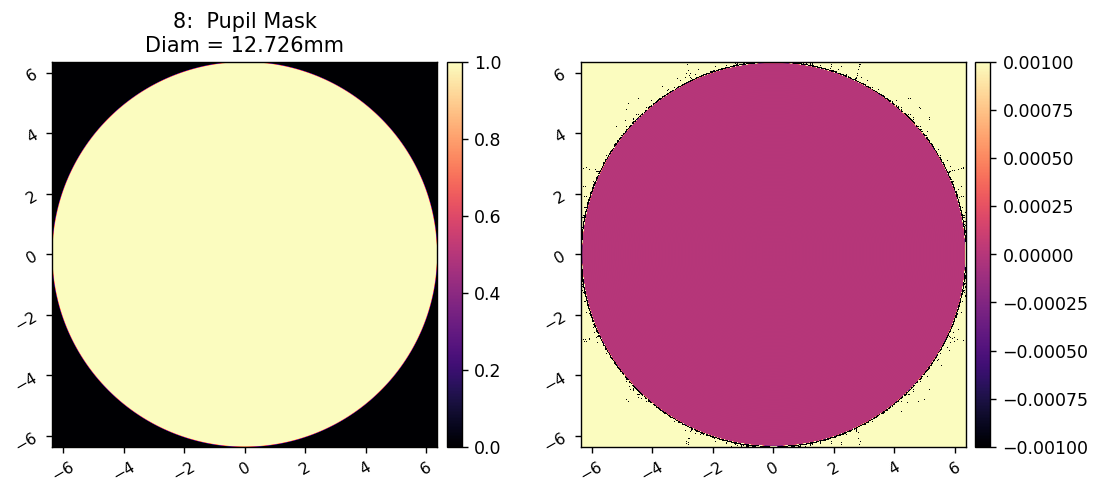

Focal Plane Correction:  0.0 mm


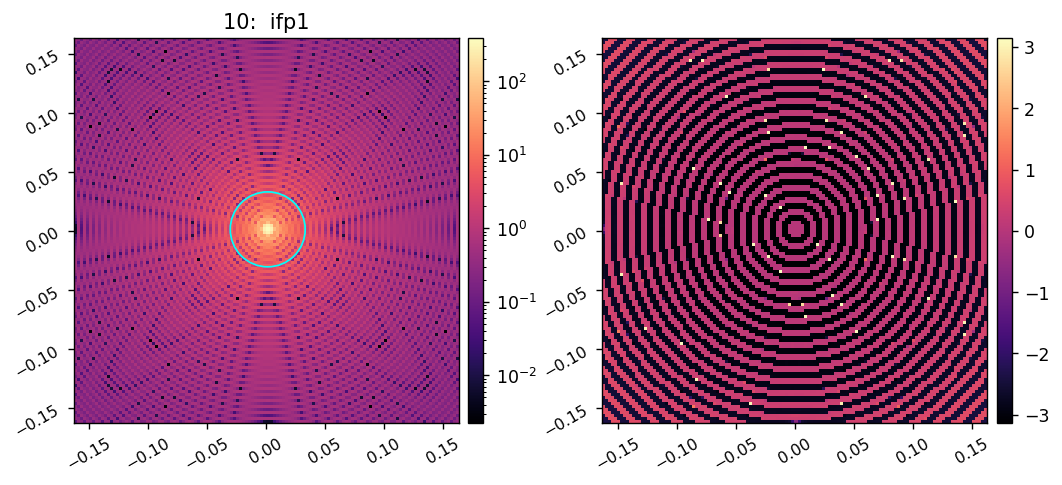

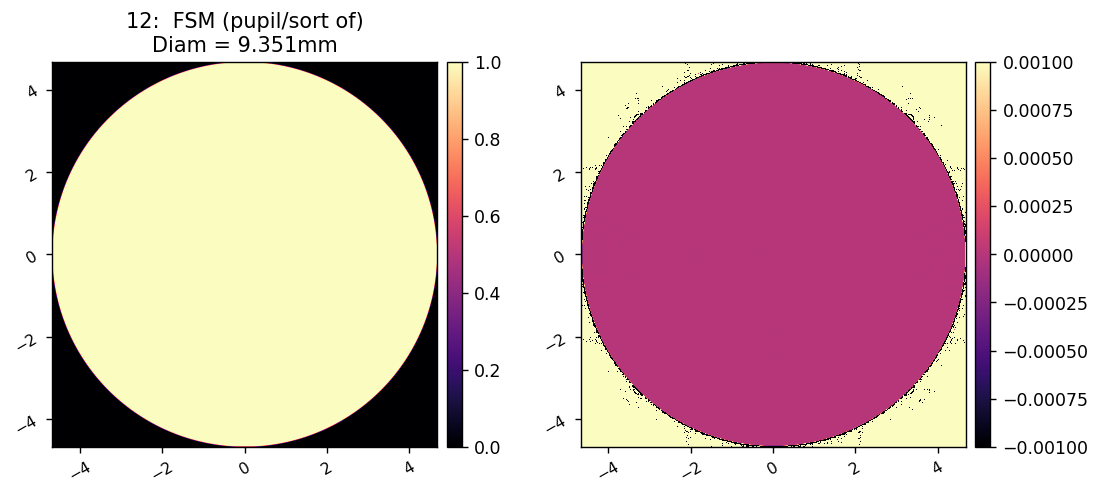

Focal Plane Correction:  0.0 mm


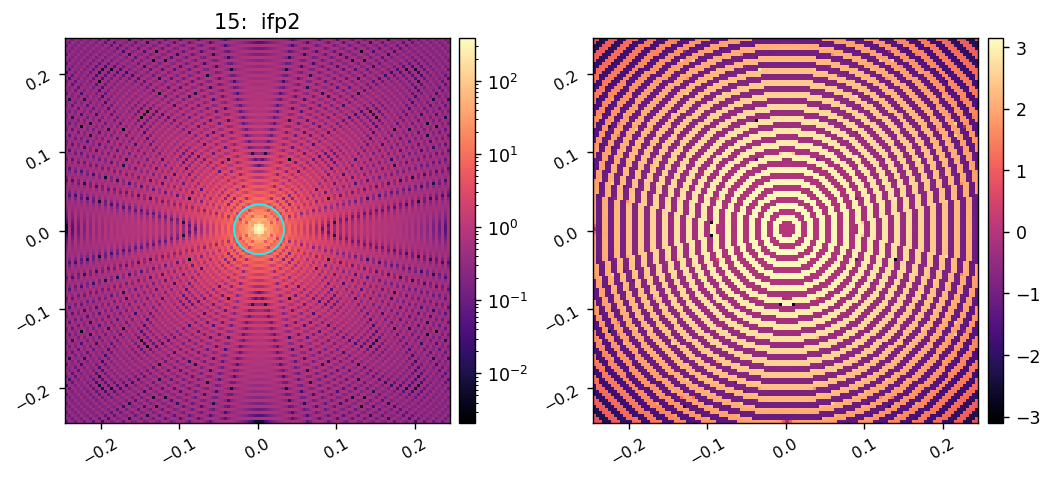

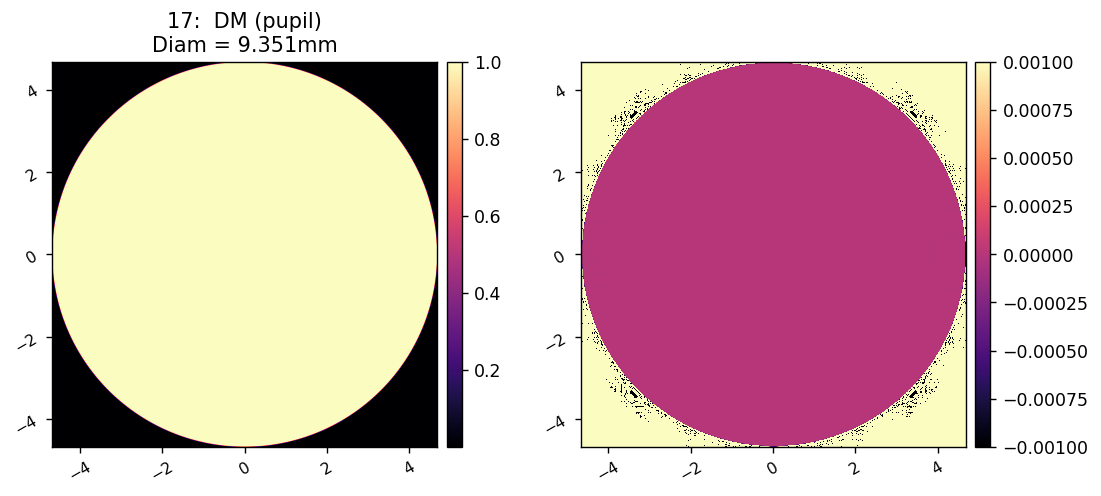

Focal Plane Correction:  -1541.0562467009754 mm


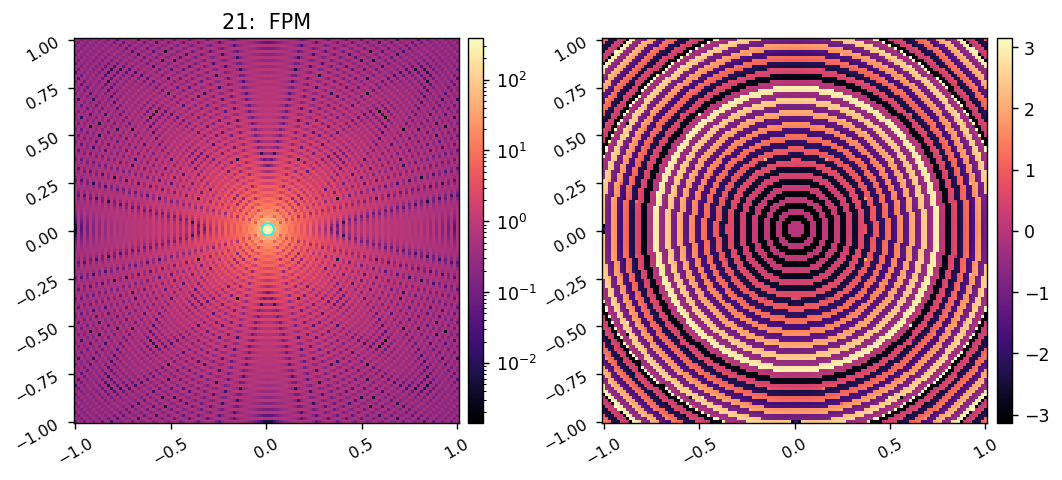

Focal Plane Correction:  0.0 mm


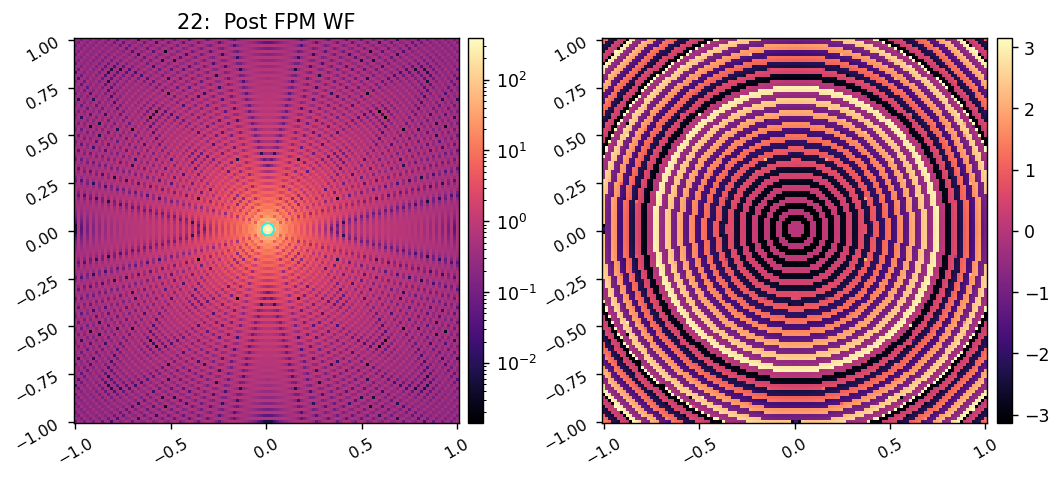

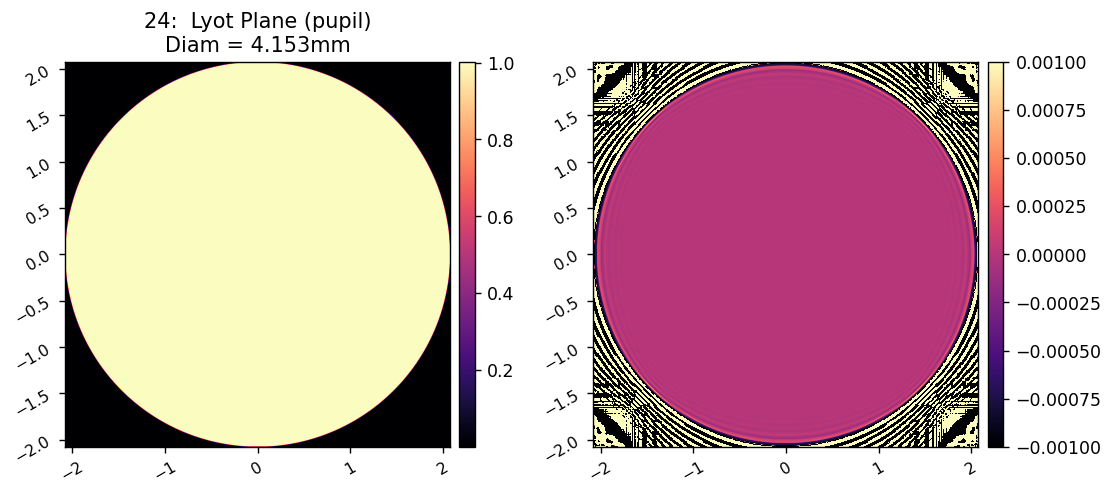

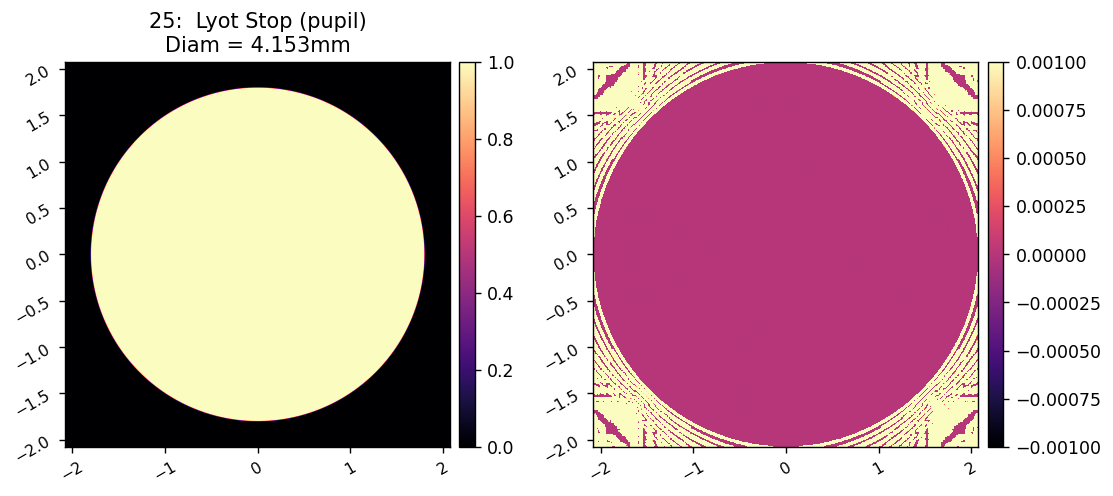

Focal Plane Correction:  0.0 mm


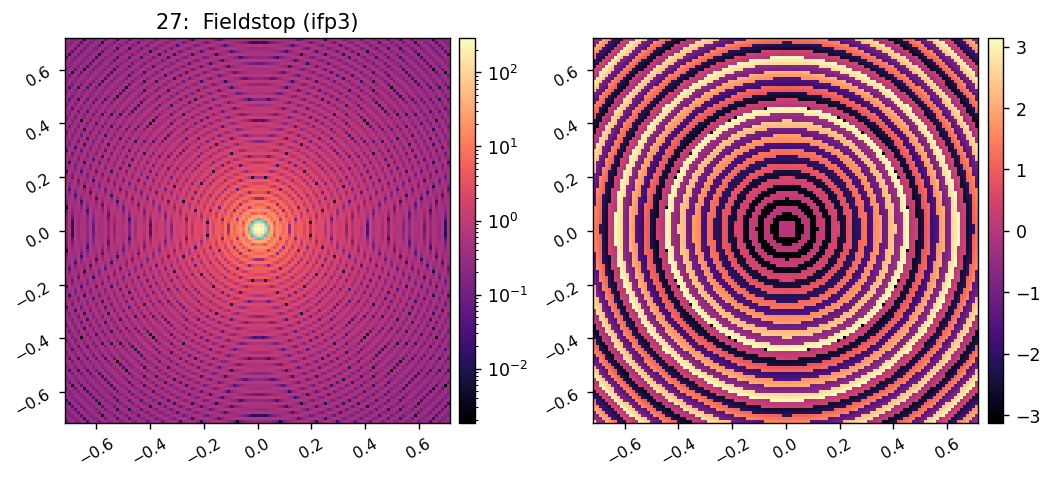

Focal Plane Correction:  0.0 mm


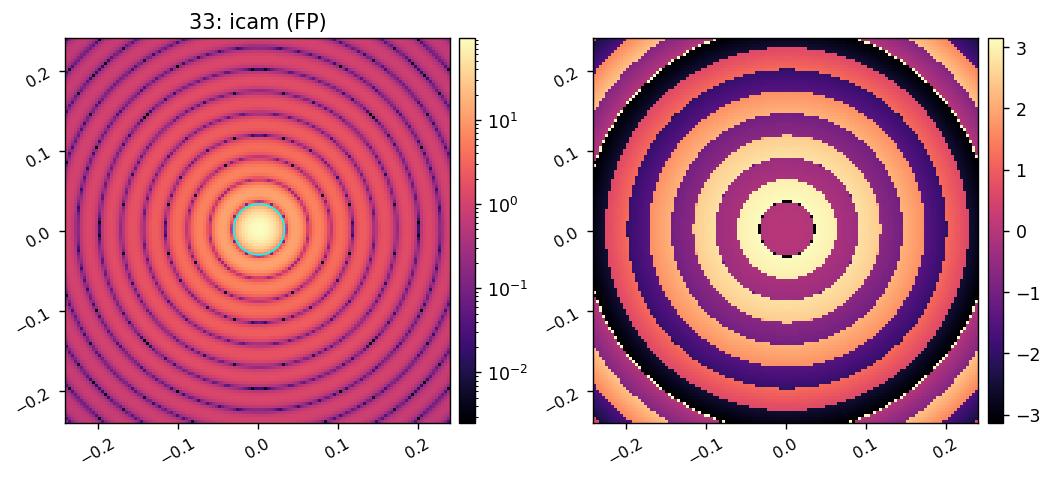

In [11]:
for i,wf in enumerate(wfs):
    # if i>9: break

    if 'fp' in wf.location.lower():
        f_corr = wf.z_w0 - wf.z
        print('Focal Plane Correction: ', f_corr.to(u.mm))
        pxscl_mm = wf.pixelscale.to_value(u.mm/u.pix)
        airy_rad = 31.752*u.um
        imshow2(wf.amplitude, wf.phase, f'{i:d}: '+wf.location[5:], pxscl=pxscl_mm, npix=128, lognorm1=True,
                patches1=[Circle((pxscl_mm/2, pxscl_mm/2), airy_rad.to_value(u.mm), color='cyan', fill=False)])
    elif 'pupil' in wf.location.lower():
        imshow2(wf.amplitude, wf.phase, f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm', 
                pxscl=wf.pixelscale.to(u.mm/u.pix), npix=M.npix, vmin2=-0.001, vmax2=0.001)
    # else:
        # imshow2(wf.amplitude, wf.phase, f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm', 
        #         pxscl=wf.pixelscale.to(u.mm/u.pix), npix=M.npix)